In [54]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import h5py

DATA_FILE = "../UCI/data/Part_1.mat"

f = h5py.File(DATA_FILE, "r")

part = f["Part_1"]

print(type(part))
print("Shape:", part.shape)
print("Dtype:", part.dtype) # 3000 recordings and each recording is a HDF5 format

<class 'h5py._hl.dataset.Dataset'>
Shape: (3000, 1)
Dtype: object


In [48]:
# Take the first recording reference
ref = part[2500, 0]

print(ref)
print(type(ref))

<HDF5 object reference>
<class 'h5py.h5r.Reference'>


In [49]:
# Access the actual recording
recording = f[ref]

print(type(recording))
print(recording.shape)
print(recording.dtype) # 61000 time samples and 3 channels (PPG, ECG, ABP)

<class 'h5py._hl.dataset.Dataset'>
(5000, 3)
float64


(5000, 3)


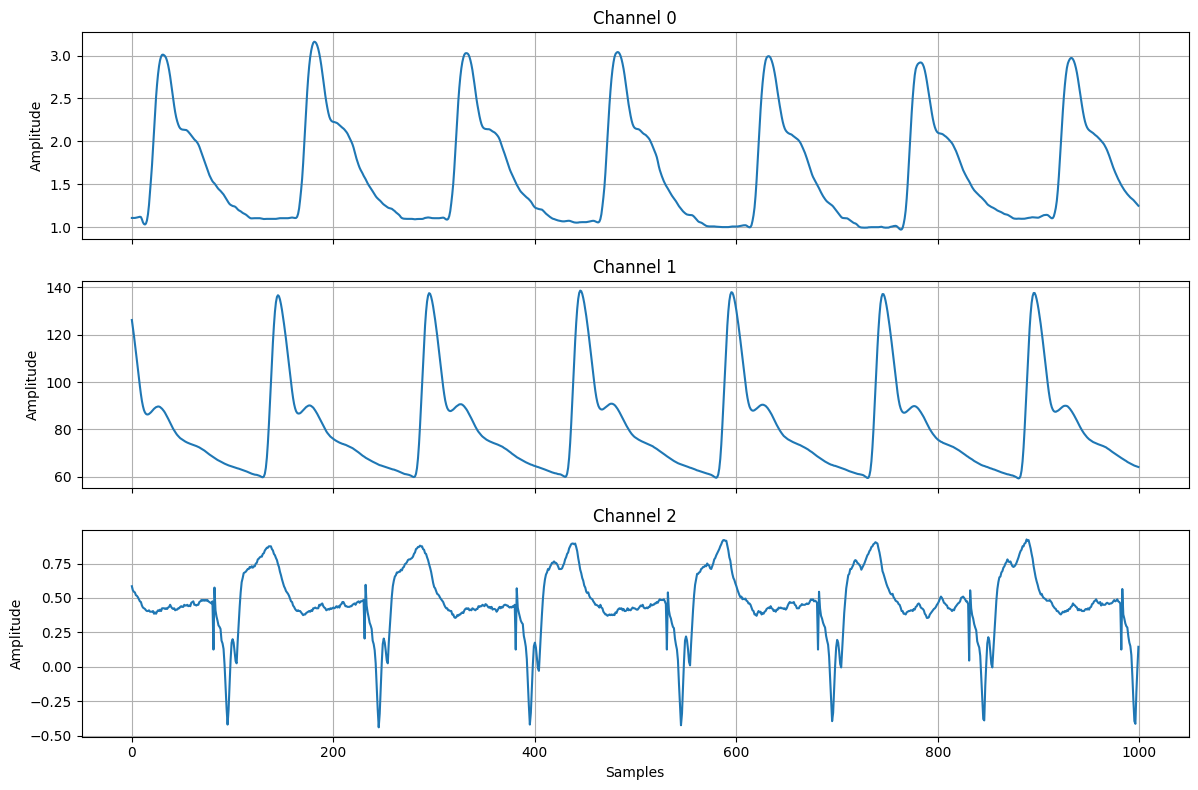

In [52]:
data = recording[:]

print(data.shape)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

channel_names = ["Channel 0", "Channel 1", "Channel 2"]

for i in range(3):
    axes[i].plot(data[:1000, i])
    axes[i].set_title(channel_names[i])
    axes[i].set_ylabel("Amplitude")
    axes[i].grid(True)

axes[-1].set_xlabel("Samples")

plt.tight_layout()
plt.show()

In [ ]:
for i in range(3):
    print(
        f"Channel {i}:",
        "min =", data[:,i].min(),
        "max =", data[:,i].max(),
        "mean =", data[:,i].mean()
    )

# Channel 0 = PPG (Photoplethysmogram)
# Channel 1 = ABP (Arterial Blood Pressure)
# Channel 2 = ECG (Electrocardiogram)

Channel 0: min = 0.0 max = 3.8748778103616814 mean = 1.7108109399308857
Channel 1: min = 58.02673919032184 max = 176.19028081424997 mean = 97.95569296466446
Channel 2: min = -1.23046875 max = 4.5 mean = -0.7326525088028168


In [57]:

ppg = data[:,0]
abp = data[:,1]

print("PPG:")
print("length:", len(ppg))
print("mean:", np.mean(ppg))
print("std:", np.std(ppg))

print("\nABP:")
print("length:", len(abp))
print("SBP:", np.max(abp))
print("DBP:", np.min(abp))

ppg_norm = (ppg - np.mean(ppg)) / np.std(ppg)

print(ppg_norm.mean())
print(ppg_norm.std())

PPG:
length: 5000
mean: 1.6129599217986312
std: 0.5739540468826131

ABP:
length: 5000
SBP: 138.66841202932602
DBP: 53.6308264910884
3.950617610826157e-16
0.9999999999999999


In [59]:
WINDOW_SIZE = 1000
STEP_SIZE = 500


def process_recording(recording):

    data = recording[:]

    # Extract signals
    ppg = data[:,0]
    abp = data[:,1]

    # Normalize PPG
    ppg = (ppg - np.mean(ppg)) / np.std(ppg)

    # BP targets
    sbp = np.max(abp)
    dbp = np.min(abp)

    X = []
    y = []

    for start in range(0, len(ppg)-WINDOW_SIZE, STEP_SIZE):

        window = ppg[start:start+WINDOW_SIZE]

        X.append(window)
        y.append([sbp, dbp])

    return np.array(X), np.array(y)

X_test, y_test = process_recording(recording)

print(X_test.shape)
print(y_test.shape)

(8, 1000)
(8, 2)
